***1- Imports & Data Loading***

used 
**import os from pathlib** 
**import Path** 
**ROOT = Path.cwd().parent**
to make root directory correct so I wouldn't have to paste directory path from root

In [3]:
ROOT = Path.cwd().parent 

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            ConfusionMatrixDisplay, mean_absolute_error,
                            mean_squared_error, r2_score)
import matplotlib.pyplot as plt
from pathlib import Path

#load UNSCALED parquets, sklearn models handle raw numbers fine
train_df = pd.read_parquet(ROOT / 'data' / 'train_scaled.parquet')
val_df = pd.read_parquet(ROOT / 'data' / 'val_scaled.parquet')
test_df = pd.read_parquet(ROOT / 'data' / 'test_scaled.parquet')

#NOT FEATURES, targets or leak info
target_cols = ['dim_flag', 'log_net_charge', 'Net Charge Billed Currency']

#define features as all cols not labeled as a target col
feature_cols = [c for c in train_df.columns if c not in target_cols]

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

#Task 1 targets: dim_flag is 1 (DIM=Y) or 0 (DIM=N)
y_train_cls = train_df['dim_flag']
y_val_cls = val_df['dim_flag']

#Task 2 targets: log_net_charge is the log-transformed shipping cost, bc of skewness
y_train_reg = train_df['log_net_charge']
y_val_reg = val_df['log_net_charge']

print(f"Features: {len(feature_cols)}")
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")




Features: 35
Train: 41,951 | Val: 5,244 | Test: 5,244


***2- Train Logistic Regression***

class_weight='balanced': our data is 40.7% DIM=Y and 59.3% DIM=N
without this, the model could just predict "N" every time and be right 59.3%
'balanced' makes the model treat each misclassified DIM=Y as more costly,
proportional to how rare DIM=Y is — forces it to actually learn the pattern

In [5]:
lr_clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

lr_clf.fit(X_train, y_train_cls)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


***3- Classification Evaluation***

.predict() gives hard labels: 0 or 1, internally it computes a probability, then uses 0.5 as the cutoff:
.predict_proba() gives the raw probability for each class
  it returns a 2D array: column 0 = P(DIM=N), column 1 = P(DIM=Y)
  they always sum to 1.0 for each row

ACCURACY: out of all predictions, what fraction were correct?

PRECISION: of all the packages we PREDICTED as DIM=Y, how many actually were?

RECALL: of all packages that ACTUALLY ARE DIM=Y, how many did we catch?

F1: the harmonic mean of precision and recall — one number that balances both.
harmonic mean punishes imbalance: if precision=1.0 but recall=0.5, F1=0.667 (not 0.75)

ROC AUC: measures how well the model separates DIM=Y from DIM=N across ALL thresholds.
1.0 = perfect separation, 0.5 = random guessing (coin flip)



In [6]:
y_val_pred = lr_clf.predict(X_val)
y_val_proba = lr_clf.predict_proba(X_val)[:,1]
accuracy = accuracy_score(y_val_cls, y_val_pred)
precision = precision_score(y_val_cls,y_val_pred)
recall = recall_score(y_val_cls, y_val_pred)
f1 = f1_score(y_val_cls, y_val_pred)
roc_auc = roc_auc_score(y_val_cls, y_val_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")



Accuracy: 0.9886
Precision: 0.9740
Recall: 0.9986
F1: 0.9861
ROC AUC: 0.9901


***4- Confusion Matrix***

a confusion matrix is a 2x2 grid that shows exactly where the model is right and wrong:

Predicted N    Predicted Y

Actual N (DIM=N)  [True Neg]     [False Pos]    ← predicted Y but was actually N (false alarm)

Actual Y (DIM=Y)  [False Neg]    [True Pos]     ← predicted N but was actually Y (MISSED DIM!)

bottom-left (False Negatives) is the dangerous cell:

these are DIM=Y packages we predicted as N → surprise cost from FedEx

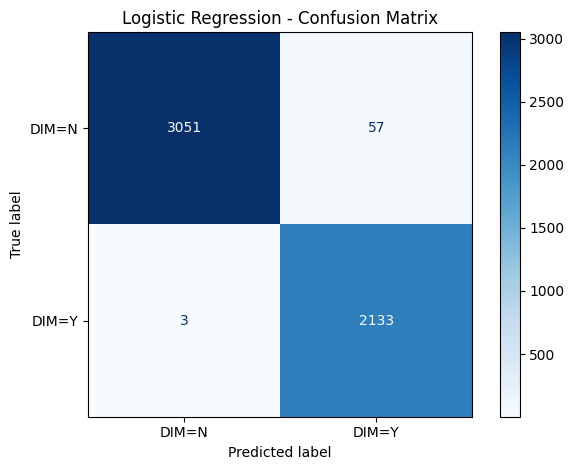

In [7]:
cm = confusion_matrix(y_val_cls, y_val_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=['DIM=N', 'DIM=Y'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.savefig( ROOT/ 'figures/baseline_cls_confusion.png', dpi=150)
plt.show()

***5- Train Linear Regression***

In [8]:
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train_reg)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


***6- Regression Evalution***

In [12]:
# predict log_net_charge on the validation set
y_val_pred_log = lr_reg.predict(X_val)

# CRITICAL: convert predictions back from log-space to actual dollars
# during preprocessing we applied np.log1p() (log(1 + x)) to compress the skewed distribution
# np.expm1() is the exact inverse: expm1(y) = e^y - 1
# without this conversion, our error metrics would be in "log-dollars" which is meaningless
y_val_pred_dollars = np.expm1(y_val_pred_log)

# get the actual dollar amounts from the original dataframe (never transformed)
y_val_actual_dollars = val_df['Net Charge Billed Currency']

# MAE (Mean Absolute Error): average of |actual - predicted| across all rows
# most interpretable metric: "on average, we're off by $X"
# example: MAE = $15.23 means the average prediction is $15.23 away from truth
mae = mean_absolute_error(y_val_actual_dollars, y_val_pred_dollars)

# RMSE (Root Mean Squared Error): sqrt of average of (actual - predicted)²
# punishes large errors more than MAE because squaring amplifies big misses
# example: if most errors are $10 but one is $500, RMSE spikes way more than MAE
# useful for catching whether the model has occasional huge blowups
rmse = np.sqrt(mean_squared_error(y_val_actual_dollars, y_val_pred_dollars))

# R² (R-squared): what fraction of the variance in shipping costs our model explains
# 1.0 = perfect predictions, 0.0 = model is as good as just predicting the average every time
# can go negative if the model is worse than just predicting the mean
r2 = r2_score(y_val_actual_dollars, y_val_pred_dollars)

print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  $8.34
RMSE: $23.70
R²:   0.6982


***7- Actual vs Predicted Scatter Plot***

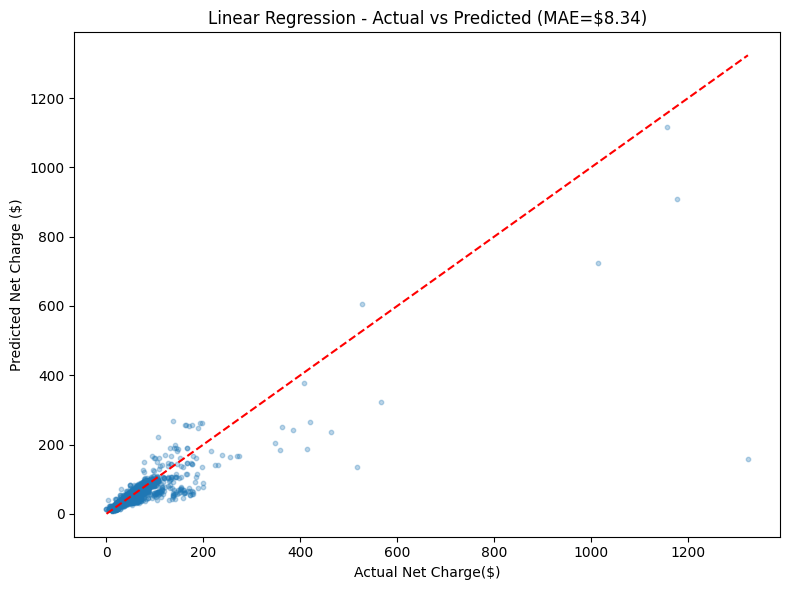

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(y_val_actual_dollars, y_val_pred_dollars, alpha=0.3, s=10)
plt.plot([0, y_val_actual_dollars.max()], [0, y_val_actual_dollars.max()], 'r--')

plt.xlabel('Actual Net Charge($)')
plt.ylabel('Predicted Net Charge ($)')
plt.title(f'Linear Regression - Actual vs Predicted (MAE=${mae:.2f})')
plt.tight_layout()
plt.savefig(ROOT / 'figures/basline_reg_scatter.png', dpi=150)
plt.show()

***8- Summary Table***

In [11]:
# print everything together so it's easy to reference later
# these numbers are the "floor" — XGBoost and PyTorch should beat all of them
print("=== BASELINE RESULTS (Validation Set) ===")
print(f"\nTask 1 - Logistic Regression:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1:        {f1:.4f}")
print(f"  ROC AUC:   {roc_auc:.4f}")
print(f"\nTask 2 - Linear Regression:")
print(f"  MAE:  ${mae:.2f}")
print(f"  RMSE: ${rmse:.2f}")
print(f"  R²:   {r2:.4f}")

=== BASELINE RESULTS (Validation Set) ===

Task 1 - Logistic Regression:
  Accuracy:  0.9886
  Precision: 0.9740
  Recall:    0.9986
  F1:        0.9861
  ROC AUC:   0.9901

Task 2 - Linear Regression:
  MAE:  $8.34
  RMSE: $23.70
  R²:   0.6982
